### CONFIGURATION: Imports, datasets loading, etc.

##### Loaded MNISTs datasets are already proceessed: 4 bit binarization, 16x16, and split for: train/val/test

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "geqie-qml" / "src" / "geqie_qml").exists():
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "geqie" / "src"))
sys.path.insert(0, str(ROOT / "geqie-qml" / "src"))

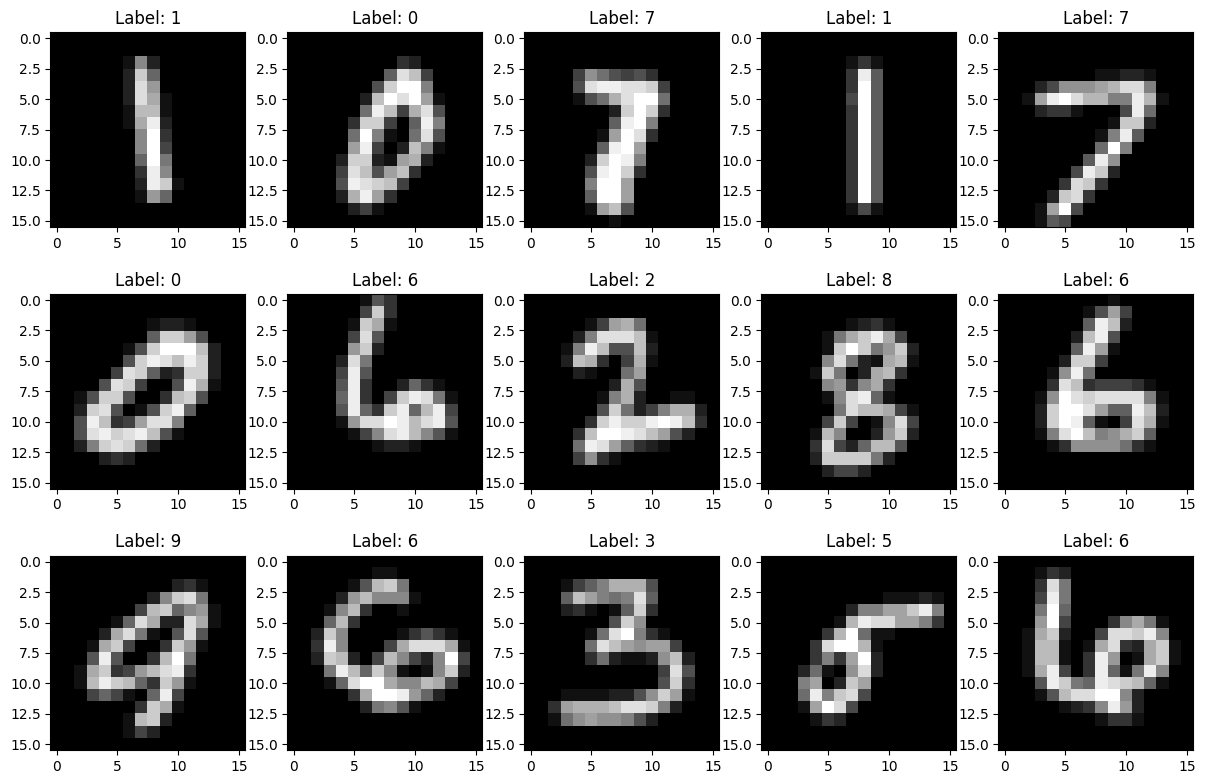

In [2]:
import joblib
import numpy as np
from experiments.QNN_integration.datasets.dataset_structure import DatasetSplit, DataBlock, DataSet
# from datasets.dataset_structure import DatasetSplit, DataBlock, DataSet
from pathlib import Path

seed = 71
rng = np.random.default_rng(seed)

mnist_digits_stratified_path = Path().absolute().parent / "QNN_integration" / "datasets" / "MNIST_Digits_5_subsets_train_val_test_16x16.joblib"
mnist_digits_stratified = joblib.load(mnist_digits_stratified_path)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 5, figsize=(12, 8))

axes = axes.flatten()
for ax in axes:
	i = rng.integers(0, len(mnist_digits_stratified.subsets[0].train.X))
	ax.imshow(mnist_digits_stratified.subsets[0].train.X[i], cmap=plt.cm.gray)
	ax.set_title("Label: " + str(mnist_digits_stratified.subsets[0].train.y[i]))

plt.tight_layout()
plt.show()

Experimental porotocol report - help functions.

In [3]:
from experiments.QNN_integration.experiment_results import (
	ExperimentResultWriter,
	count_trainable_parameters,
	print_epoch_table_footer,
	print_epoch_table_header,
	print_epoch_table_row,
	print_experiment_report,
	print_metrics_report,
	print_summary_report,
)


# GEQIE EXPERIMENTS
We are using GEQIE in order to encode feature vector for QNN

Experiment A: FRQI encoding + VQC + Dense

In [4]:
import copy
import glob
import numpy as np
import os

from multiprocessing import cpu_count
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
	accuracy_score,
	precision_score,
	recall_score,
	f1_score,
	confusion_matrix
)

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import zz_feature_map
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit_machine_learning.connectors import TorchConnector
from qiskit_machine_learning.neural_networks import SamplerQNN
from qiskit_machine_learning.gradients import ParamShiftSamplerGradient, SPSASamplerGradient

import geqie
from geqie.encodings import frqi

from geqie_qml import VQCLayer, MatrixDataset, compute_and_save_circuits


class TorchDatasetSplit(Dataset):
	def __init__(self, X, y, x_dtype=torch.float32, y_dtype=torch.long):
		self.X = torch.tensor(X, dtype=x_dtype)
		self.y = torch.tensor(y, dtype=y_dtype)

	def __len__(self):
		return len(self.X)

	def __getitem__(self, idx):
		return self.X[idx], self.y[idx]
	
class QNN_GEQIE_FRQI(nn.Module):
	def __init__(self,
					num_qubits: int = 4,
					num_layers: int = 3,
					num_classes: int = 2,
					shots: int = 1024,
					scale_output: bool = True,
					encoding_method: str = "frqi",
					):
		super().__init__()
		self.num_qubits = num_qubits
		self.num_layers = num_layers
		self.num_classes = num_classes
		self.num_shots = shots
		self.scale_output = scale_output
		self.encoding_method = encoding_method

		# Trainable quantum weights, registered as a proper nn.Parameter so
		# that optimisers, state_dict, and requires_grad all work out of the box.
		# Workers reconstruct the circuit independently via _build_vqc_circuit,
		# so the Qiskit QuantumCircuit object does not need to be stored here.
		num_params = 3 * num_qubits * num_layers
		self.quantum_weight = nn.Parameter(
			torch.empty(num_params).uniform_(-np.pi, np.pi)
		)
		self.vqc_layer = VQCLayer(num_qubits=num_qubits, num_layers=num_layers)
		self.classical_head = nn.Linear(2**num_qubits, num_classes)
		self.softmax = nn.LogSoftmax(dim=-1)

	def forward(self, x: torch.Tensor) -> torch.Tensor:
		x = self.vqc_layer(x)	# QNN: (N, num_qubits) -> (N, 2**num_qubits)
		x = self.classical_head(x)		# Dense: (N, 2**num_qubits) -> (N, num_classes)
		x = self.softmax(x)				# Softmax: (N, num_classes) -> (N, num_classes) with log-probabilities
		return x



def numpy_labels_to_torch(y_np: np.ndarray, device: str = "cpu") -> torch.Tensor:
	y_np = np.asarray(y_np)
	return torch.tensor(y_np, dtype=torch.long, device=device)


def compute_classification_metrics(y_true, y_pred):
	return {
		"accuracy": float(accuracy_score(y_true, y_pred)),
		"precision": float(precision_score(y_true, y_pred, average="weighted", zero_division=0)),
		"recall": float(recall_score(y_true, y_pred, average="weighted", zero_division=0)),
		"f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
	}


def evaluate_cnn_qnn_model(model, data_loader: DataLoader, f_loss, device="cpu", batch_size=16):
	model.eval()

	all_losses = []
	all_preds = []
	all_true = []

	with torch.no_grad():
		for X_val, y_val in data_loader:
			X_val = X_val.to(device)
			y_val = y_val.to(device)

			logits = model(X_val)
			loss = f_loss(logits, y_val)
			preds = torch.argmax(logits, dim=1)

			all_losses.append(loss.item())
			all_preds.extend(preds.cpu().numpy().tolist())
			all_true.extend(y_val.cpu().numpy().tolist())

	metrics = compute_classification_metrics(all_true, all_preds)

	return {
		"loss": float(np.mean(all_losses)) if len(all_losses) > 0 else 0.0,
		"accuracy": metrics["accuracy"],
		"precision": metrics["precision"],
		"recall": metrics["recall"],
		"f1": metrics["f1"],
		"y_true": all_true,
		"y_pred": all_preds,
	}

def load_circuits(geqie_circuits_path: str,
				  batch_size: int = 16) -> tuple[DataLoader, DataLoader, DataLoader]:
	train_files = sorted(glob.glob(f"{geqie_circuits_path}/train/*.npz"))
	val_files = sorted(glob.glob(f"{geqie_circuits_path}/val/*.npz"))
	test_files = sorted(glob.glob(f"{geqie_circuits_path}/test/*.npz"))

	train_dataset = MatrixDataset(train_files)
	train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

	val_dataset = MatrixDataset(val_files)
	val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

	test_dataset = MatrixDataset(test_files)
	test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

	return train_dataloader, val_dataloader, test_dataloader


def train_one_block_frqi_qnn(
	num_classes=10,
	num_qubits=12,
	num_layers=1,
	epochs=20,
	batch_size=16,
	device="cpu",
	geqie_circuits_path=None,
	verbose=True,
	report_context=None,
	early_stopping=True,
    patience=5,
    min_delta=1e-4,
):

	# transform the datablock into set of matrices, encoded by GEQIE core.
	train_loader, val_loader, test_loader = load_circuits(geqie_circuits_path=geqie_circuits_path, batch_size=batch_size)

	vqc_layer = VQCLayer(
		num_qubits=num_qubits,
		num_layers=num_layers
	).to(device)
	
	model = nn.Sequential(
		vqc_layer,
		nn.Linear(2 ** num_qubits, num_classes),
		nn.LogSoftmax(dim=-1),
	)
	if report_context is not None and report_context.get("model_architecture") and "trainable_parameters" not in report_context:
		report_context = {
			**report_context,
			"trainable_parameters": count_trainable_parameters(model),
		}

	f_loss = nn.NLLLoss()
	optimizer = Adam(([
		{"params": model[0].parameters(), "lr": 0.001},
		{"params": model[1].parameters(), "lr": 0.01},
	]))


	history = {
		"train_loss": [],
		"train_accuracy": [],
		"train_precision": [],
		"train_recall": [],
		"train_f1": [],
		"val_loss": [],
		"val_accuracy": [],
		"val_precision": [],
		"val_recall": [],
		"val_f1": [],
	}

	best_val_loss = np.inf
	best_model_state = None
	best_epoch = -1
	epochs_without_improvement = 0

	with vqc_layer.parallel_context(num_workers=max(1, cpu_count() - 1)):
		for epoch in range(epochs):
			model.train()

			epoch_losses = []
			epoch_preds = []
			epoch_true = []

			for X_batch, y_batch in train_loader:
				X_batch = X_batch.to(device)
				y_batch = y_batch.to(device)

				optimizer.zero_grad()
				output = model(X_batch)
				loss = f_loss(output, y_batch)
				loss.backward()			
				optimizer.step()

				epoch_losses.append(loss.item())
				preds = torch.argmax(output, dim=1)
				epoch_preds.extend(preds.detach().cpu().numpy().tolist())
				epoch_true.extend(y_batch.detach().cpu().numpy().tolist())

			train_metrics = compute_classification_metrics(epoch_true, epoch_preds)
			train_loss = float(np.mean(epoch_losses)) if len(epoch_losses) > 0 else 0.0

			val_results = evaluate_cnn_qnn_model(
				model=model,
				data_loader=val_loader,
				f_loss=f_loss,
				device=device,
				batch_size=batch_size
			)

			history["train_loss"].append(train_loss)
			history["train_accuracy"].append(train_metrics["accuracy"])
			history["train_precision"].append(train_metrics["precision"])
			history["train_recall"].append(train_metrics["recall"])
			history["train_f1"].append(train_metrics["f1"])

			history["val_loss"].append(val_results["loss"])
			history["val_accuracy"].append(val_results["accuracy"])
			history["val_precision"].append(val_results["precision"])
			history["val_recall"].append(val_results["recall"])
			history["val_f1"].append(val_results["f1"])

			if val_results["loss"] < best_val_loss - min_delta:
				best_val_loss = val_results["loss"]
				best_epoch = epoch
				best_model_state = copy.deepcopy(model.state_dict())
				epochs_without_improvement = 0
			else:
				epochs_without_improvement += 1

			if early_stopping and epochs_without_improvement >= patience:
				if verbose:
					print(f"Early stopping at epoch {epoch + 1}, best epoch was {best_epoch + 1}")
				break

			if verbose:
				if epoch == 0:
					if report_context is not None:
						print_experiment_report(**report_context)
					print_epoch_table_header()
				print_epoch_table_row(
					epoch=epoch + 1,
					epochs=epochs,
					train_loss=train_loss,
					train_metrics=train_metrics,
					val_loss=val_results["loss"],
					val_metrics=val_results
				)			

		if verbose and epochs > 0:
			print_epoch_table_footer()

		if best_model_state is not None:
			model.load_state_dict(best_model_state)

		test_results = evaluate_cnn_qnn_model(
			model=model,
			data_loader=test_loader,
			f_loss=f_loss,
			device=device,
			batch_size=batch_size
		)

		test_cm = confusion_matrix(
			test_results["y_true"],
			test_results["y_pred"],
			labels=list(range(num_classes))
		)

		if verbose:
			print_metrics_report(
				title="TEST RESULTS",
				metrics={
					"loss": test_results["loss"],
					"accuracy": test_results["accuracy"],
					"precision": test_results["precision"],
					"recall": test_results["recall"],
					"f1": test_results["f1"],
				},
				matrix=test_cm 
			)

		return {
			"model": model,
			"history": history,
			"test_metrics": {
				"loss": test_results["loss"],
				"accuracy": test_results["accuracy"],
				"precision": test_results["precision"],
				"recall": test_results["recall"],
				"f1": test_results["f1"],
			},
			"confusion_matrix": test_cm,
			"y_true": test_results["y_true"],
			"y_pred": test_results["y_pred"],
		}


def train_all_subsets_frqi_qnn(
	dataset: DataSet,
	create_circuits: bool = True,
	encoding_method = frqi,
	num_classes=10,
	num_qubits=12,
	num_layers=1,
	epochs=10,
	batch_size=32,
	device="cpu",
	geqie_circuits_path="./datasets/circuits",
	verbose=True,
	save_results=True,
	pipeline_name="Experiment_A_FRQI"
):
	all_results = []
	results_writer = ExperimentResultWriter(pipeline_name=pipeline_name) if save_results else None

	cwd = os.getcwd()
	save_dir = os.path.join(cwd, geqie_circuits_path)
	if create_circuits:
		for subset_idx, data_block in enumerate(dataset.subsets):
			compute_and_save_circuits(data=data_block.train.X, 
								labels=data_block.train.y, 
								geqie_encoding=encoding_method, 
								save_dir=os.path.join(save_dir, f"subset_{subset_idx + 1}", "train"))

			compute_and_save_circuits(data=data_block.val.X, 
									labels=data_block.val.y, 
									geqie_encoding=encoding_method, 
									save_dir=os.path.join(save_dir, f"subset_{subset_idx + 1}", "val"))
			
			compute_and_save_circuits(data=data_block.test.X, 
									labels=data_block.test.y, 
									geqie_encoding=encoding_method,
									save_dir=os.path.join(save_dir, f"subset_{subset_idx + 1}", "test"))

	for subset_idx, data_block in enumerate(dataset.subsets):
		report_context = {
			"title": "EXPERIMENTAL PROTOCOL REPORT",
			"dataset_name": "MNIST digits stratified",
			"classifier_name": "FRQI + QNN + Dense",
			"model_architecture": "GEQIE/FRQI-encoded circuits -> VQCLayer(num_qubits, num_layers) -> Linear(2**num_qubits, num_classes) -> LogSoftmax" if subset_idx == 0 else None,
			"subset_name": f"{subset_idx + 1}/{len(dataset.subsets)}",
			"split_sizes": {
				"train": len(data_block.train.X),
				"val": len(data_block.val.X),
				"test": len(data_block.test.X),
			},
			"training_setup": {
				"epochs": epochs,
				"batch_size": batch_size,
				"device": device,
				"qnn_lr": 0.001,
				"head_lr": 0.01,
			},
			"model_setup": {
				"num_classes": num_classes,
				"num_qubits": num_qubits,
				"num_layers": num_layers,
			},
		}

		result = train_one_block_frqi_qnn(
			geqie_circuits_path=os.path.join(save_dir, f"subset_{subset_idx + 1}"),
			num_classes=num_classes,
			num_qubits=num_qubits,
			num_layers=num_layers,
			epochs=epochs,
			batch_size=batch_size,
			device=device,
			verbose=verbose,
			report_context=report_context
		)

		all_results.append(result)

		if results_writer is not None:
			results_writer.save_subset(
				subset_index=subset_idx + 1,
				subset_count=len(dataset.subsets),
				report_context=report_context,
				history=result["history"],
				test_metrics=result["test_metrics"],
				confusion_matrix=result["confusion_matrix"],
				model=result["model"],
			)

	accuracies = [r["test_metrics"]["accuracy"] for r in all_results]
	precisions = [r["test_metrics"]["precision"] for r in all_results]
	recalls = [r["test_metrics"]["recall"] for r in all_results]
	f1s = [r["test_metrics"]["f1"] for r in all_results]

	summary = {
		"accuracy_mean": float(np.mean(accuracies)),
		"accuracy_std": float(np.std(accuracies)),
		"precision_mean": float(np.mean(precisions)),
		"precision_std": float(np.std(precisions)),
		"recall_mean": float(np.mean(recalls)),
		"recall_std": float(np.std(recalls)),
		"f1_mean": float(np.mean(f1s)),
		"f1_std": float(np.std(f1s)),
	}

	if verbose:
		print_summary_report("FINAL SUMMARY ACROSS SUBSETS", summary)

	if results_writer is not None:
		results_writer.save_final_summary(summary=summary, subset_results=all_results)

	return {
		"subset_results": all_results,
		"summary": summary,
		"results_dir": str(results_writer.run_dir) if results_writer is not None else None,
	}

frqi_qnn_results = train_all_subsets_frqi_qnn(
	dataset=mnist_digits_stratified,
	create_circuits=False,
	encoding_method="frqi",
	num_classes=10,
	num_qubits=9,
	num_layers=1,
	epochs=10,
	batch_size=16,
	device="cpu",
	verbose=True
)

######################################################################################################################
#                                            EXPERIMENTAL PROTOCOL REPORT                                            #
######################################################################################################################
# DATE      : 30-04-2026                                                                                             #
# TIME      : 09:23                                                                                                  #
# DATASET   : MNIST digits stratified                                                                                #
# CLASSIFIER: FRQI + QNN + Dense                                                                                     #
# SUBSET    : 1/5                                                                                                    #
# SPLITS    : train=921, val=231, test=288      

Experiment B: NEQR (4 bits) encoding + VQC + Dense

In [ ]:
import copy
import glob
import numpy as np
import os

from multiprocessing import cpu_count
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
	accuracy_score,
	precision_score,
	recall_score,
	f1_score,
	confusion_matrix
)

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import zz_feature_map
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit_machine_learning.connectors import TorchConnector
from qiskit_machine_learning.neural_networks import SamplerQNN
from qiskit_machine_learning.gradients import ParamShiftSamplerGradient, SPSASamplerGradient

import geqie
from geqie.encodings import neqr

from geqie_qml import VQCLayer, MatrixDataset, compute_and_save_circuits


class TorchDatasetSplit(Dataset):
	def __init__(self, X, y, x_dtype=torch.float32, y_dtype=torch.long):
		self.X = torch.tensor(X, dtype=x_dtype)
		self.y = torch.tensor(y, dtype=y_dtype)

	def __len__(self):
		return len(self.X)

	def __getitem__(self, idx):
		return self.X[idx], self.y[idx]
	
class QNN_GEQIE_NEQR(nn.Module):
	def __init__(self,
					num_qubits: int = 4,
					num_layers: int = 3,
					num_classes: int = 2,
					shots: int = 1024,
					scale_output: bool = True,
					encoding_method: str = "neqr",
					):
		super().__init__()
		self.num_qubits = num_qubits
		self.num_layers = num_layers
		self.num_classes = num_classes
		self.num_shots = shots
		self.scale_output = scale_output
		self.encoding_method = encoding_method

		# Trainable quantum weights, registered as a proper nn.Parameter so
		# that optimisers, state_dict, and requires_grad all work out of the box.
		# Workers reconstruct the circuit independently via _build_vqc_circuit,
		# so the Qiskit QuantumCircuit object does not need to be stored here.
		num_params = 3 * num_qubits * num_layers
		self.quantum_weight = nn.Parameter(
			torch.empty(num_params).uniform_(-np.pi, np.pi)
		)
		self.vqc_layer = VQCLayer(num_qubits=num_qubits, num_layers=num_layers)
		self.classical_head = nn.Linear(2**num_qubits, num_classes)
		self.softmax = nn.LogSoftmax(dim=-1)

	def forward(self, x: torch.Tensor) -> torch.Tensor:
		x = self.vqc_layer(x)	# QNN: (N, num_qubits) -> (N, 2**num_qubits)
		x = self.classical_head(x)		# Dense: (N, 2**num_qubits) -> (N, num_classes)
		x = self.softmax(x)				# Softmax: (N, num_classes) -> (N, num_classes) with log-probabilities
		return x



def numpy_labels_to_torch(y_np: np.ndarray, device: str = "cpu") -> torch.Tensor:
	y_np = np.asarray(y_np)
	return torch.tensor(y_np, dtype=torch.long, device=device)


def compute_classification_metrics(y_true, y_pred):
	return {
		"accuracy": float(accuracy_score(y_true, y_pred)),
		"precision": float(precision_score(y_true, y_pred, average="weighted", zero_division=0)),
		"recall": float(recall_score(y_true, y_pred, average="weighted", zero_division=0)),
		"f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
	}


def evaluate_model(model, data_loader: DataLoader, f_loss, device="cpu", batch_size=16):
	model.eval()

	all_losses = []
	all_preds = []
	all_true = []

	with torch.no_grad():
		for X_val, y_val in data_loader:
			X_val = X_val.to(device)
			y_val = y_val.to(device)

			logits = model(X_val)
			loss = f_loss(logits, y_val)
			preds = torch.argmax(logits, dim=1)

			all_losses.append(loss.item())
			all_preds.extend(preds.cpu().numpy().tolist())
			all_true.extend(y_val.cpu().numpy().tolist())

	metrics = compute_classification_metrics(all_true, all_preds)

	return {
		"loss": float(np.mean(all_losses)) if len(all_losses) > 0 else 0.0,
		"accuracy": metrics["accuracy"],
		"precision": metrics["precision"],
		"recall": metrics["recall"],
		"f1": metrics["f1"],
		"y_true": all_true,
		"y_pred": all_preds,
	}

def load_circuits(geqie_circuits_path: str,
				  batch_size: int = 16) -> tuple[DataLoader, DataLoader, DataLoader]:
	train_files = sorted(glob.glob(f"{geqie_circuits_path}/train/*.npz"))
	val_files = sorted(glob.glob(f"{geqie_circuits_path}/val/*.npz"))
	test_files = sorted(glob.glob(f"{geqie_circuits_path}/test/*.npz"))

	train_dataset = MatrixDataset(train_files)
	train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

	val_dataset = MatrixDataset(val_files)
	val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

	test_dataset = MatrixDataset(test_files)
	test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

	return train_dataloader, val_dataloader, test_dataloader


def train_one_block_neqr_qnn(
	num_classes=10,
	num_qubits=12,
	num_layers=1,
	epochs=20,
	batch_size=16,
	device="cpu",
	geqie_circuits_path=None,
	verbose=True,
	report_context=None,
	early_stopping=True,
    patience=5,
    min_delta=1e-4,
):
	# transform the datablock into set of matrices, encoded by GEQIE core.
	train_loader, val_loader, test_loader = load_circuits(geqie_circuits_path=geqie_circuits_path, batch_size=batch_size)

	vqc_layer = VQCLayer(
		num_qubits=num_qubits,
		num_layers=num_layers
	).to(device)
	
	model = nn.Sequential(
		vqc_layer,
		nn.Linear(2 ** num_qubits, num_classes),
		nn.LogSoftmax(dim=-1),
	)
	if report_context is not None and report_context.get("model_architecture") and "trainable_parameters" not in report_context:
		report_context = {
			**report_context,
			"trainable_parameters": count_trainable_parameters(model),
		}

	f_loss = nn.NLLLoss()
	optimizer = Adam(([
		{"params": model[0].parameters(), "lr": 0.001},
		{"params": model[1].parameters(), "lr": 0.01},
	]))


	history = {
		"train_loss": [],
		"train_accuracy": [],
		"train_precision": [],
		"train_recall": [],
		"train_f1": [],
		"val_loss": [],
		"val_accuracy": [],
		"val_precision": [],
		"val_recall": [],
		"val_f1": [],
	}

	best_val_loss = np.inf
	best_model_state = None
	best_epoch = -1
	epochs_without_improvement = 0

	with vqc_layer.parallel_context(num_workers=max(1, cpu_count() - 1)):
		for epoch in range(epochs):
			model.train()

			epoch_losses = []
			epoch_preds = []
			epoch_true = []

			for X_batch, y_batch in train_loader:
				X_batch = X_batch.to(device)
				y_batch = y_batch.to(device)

				optimizer.zero_grad()
				output = model(X_batch)
				loss = f_loss(output, y_batch)
				loss.backward()			
				optimizer.step()

				epoch_losses.append(loss.item())
				preds = torch.argmax(output, dim=1)
				epoch_preds.extend(preds.detach().cpu().numpy().tolist())
				epoch_true.extend(y_batch.detach().cpu().numpy().tolist())

			train_metrics = compute_classification_metrics(epoch_true, epoch_preds)
			train_loss = float(np.mean(epoch_losses)) if len(epoch_losses) > 0 else 0.0

			val_results = evaluate_model(
				model=model,
				data_loader=val_loader,
				f_loss=f_loss,
				device=device,
				batch_size=batch_size
			)

			history["train_loss"].append(train_loss)
			history["train_accuracy"].append(train_metrics["accuracy"])
			history["train_precision"].append(train_metrics["precision"])
			history["train_recall"].append(train_metrics["recall"])
			history["train_f1"].append(train_metrics["f1"])

			history["val_loss"].append(val_results["loss"])
			history["val_accuracy"].append(val_results["accuracy"])
			history["val_precision"].append(val_results["precision"])
			history["val_recall"].append(val_results["recall"])
			history["val_f1"].append(val_results["f1"])

			if val_results["loss"] < best_val_loss - min_delta:
				best_val_loss = val_results["loss"]
				best_epoch = epoch
				best_model_state = copy.deepcopy(model.state_dict())
				epochs_without_improvement = 0
			else:
				epochs_without_improvement += 1

			if early_stopping and epochs_without_improvement >= patience:
				if verbose:
					print(f"Early stopping at epoch {epoch + 1}, best epoch was {best_epoch + 1}")
				break

			if verbose:
				if epoch == 0:
					if report_context is not None:
						print_experiment_report(**report_context)
					print_epoch_table_header()
				print_epoch_table_row(
					epoch=epoch + 1,
					epochs=epochs,
					train_loss=train_loss,
					train_metrics=train_metrics,
					val_loss=val_results["loss"],
					val_metrics=val_results
				)			

		if verbose and epochs > 0:
			print_epoch_table_footer()

		if best_model_state is not None:
			model.load_state_dict(best_model_state)

		test_results = evaluate_model(
			model=model,
			data_loader=test_loader,
			f_loss=f_loss,
			device=device,
			batch_size=batch_size
		)

		test_cm = confusion_matrix(
			test_results["y_true"],
			test_results["y_pred"],
			labels=list(range(num_classes))
		)

		if verbose:
			print_metrics_report(
				title="TEST RESULTS",
				metrics={
					"loss": test_results["loss"],
					"accuracy": test_results["accuracy"],
					"precision": test_results["precision"],
					"recall": test_results["recall"],
					"f1": test_results["f1"],
				},
				matrix=test_cm 
			)

		return {
			"model": model,
			"history": history,
			"test_metrics": {
				"loss": test_results["loss"],
				"accuracy": test_results["accuracy"],
				"precision": test_results["precision"],
				"recall": test_results["recall"],
				"f1": test_results["f1"],
			},
			"confusion_matrix": test_cm,
			"y_true": test_results["y_true"],
			"y_pred": test_results["y_pred"],
		}


def train_all_subsets_neqr_qnn(
	dataset: DataSet,
	create_circuits: bool = True,
	encoding_method = neqr,
	num_classes=10,
	num_qubits=12,
	num_layers=1,
	epochs=10,
	batch_size=32,
	device="cpu",
	geqie_circuits_path="./datasets/circuits",
	verbose=True,
	bitrate=4,
	save_results=True,
	pipeline_name="Experiment_B_NEQR"
):
	all_results = []
	results_writer = ExperimentResultWriter(pipeline_name=pipeline_name) if save_results else None

	cwd = os.getcwd()
	save_dir = os.path.join(cwd, geqie_circuits_path)
	if create_circuits:
		for subset_idx, data_block in enumerate(dataset.subsets):
			compute_and_save_circuits(data=data_block.train.X, 
								labels=data_block.train.y, 
								geqie_encoding=encoding_method, 
								save_dir=os.path.join(save_dir, f"subset_{subset_idx + 1}", "train"), bitrate=bitrate)

			compute_and_save_circuits(data=data_block.val.X, 
									labels=data_block.val.y, 
									geqie_encoding=encoding_method, 
									save_dir=os.path.join(save_dir, f"subset_{subset_idx + 1}", "val"), bitrate=bitrate)
			
			compute_and_save_circuits(data=data_block.test.X, 
									labels=data_block.test.y, 
									geqie_encoding=encoding_method,
									save_dir=os.path.join(save_dir, f"subset_{subset_idx + 1}", "test"), bitrate=bitrate)

	for subset_idx, data_block in enumerate(dataset.subsets):
		report_context = {
			"title": "EXPERIMENTAL PROTOCOL REPORT",
			"dataset_name": "MNIST digits stratified",
			"classifier_name": "NEQR + QNN + Dense",
			"model_architecture": "GEQIE/NEQR-encoded circuits -> VQCLayer(num_qubits, num_layers) -> Linear(2**num_qubits, num_classes) -> LogSoftmax" if subset_idx == 0 else None,
			"subset_name": f"{subset_idx + 1}/{len(dataset.subsets)}",
			"split_sizes": {
				"train": len(data_block.train.X),
				"val": len(data_block.val.X),
				"test": len(data_block.test.X),
			},
			"training_setup": {
				"epochs": epochs,
				"batch_size": batch_size,
				"device": device,
				"qnn_lr": 0.001,
				"head_lr": 0.01,
			},
			"model_setup": {
				"num_classes": num_classes,
				"num_qubits": num_qubits,
				"num_layers": num_layers,
			},
		}

		result = train_one_block_neqr_qnn(
			geqie_circuits_path=os.path.join(save_dir, f"subset_{subset_idx + 1}"),
			num_classes=num_classes,
			num_qubits=num_qubits,
			num_layers=num_layers,
			epochs=epochs,
			batch_size=batch_size,
			device=device,
			verbose=verbose,
			report_context=report_context
		)

		all_results.append(result)

		if results_writer is not None:
			results_writer.save_subset(
				subset_index=subset_idx + 1,
				subset_count=len(dataset.subsets),
				report_context=report_context,
				history=result["history"],
				test_metrics=result["test_metrics"],
				confusion_matrix=result["confusion_matrix"],
				model=result["model"],
			)

	accuracies = [r["test_metrics"]["accuracy"] for r in all_results]
	precisions = [r["test_metrics"]["precision"] for r in all_results]
	recalls = [r["test_metrics"]["recall"] for r in all_results]
	f1s = [r["test_metrics"]["f1"] for r in all_results]

	summary = {
		"accuracy_mean": float(np.mean(accuracies)),
		"accuracy_std": float(np.std(accuracies)),
		"precision_mean": float(np.mean(precisions)),
		"precision_std": float(np.std(precisions)),
		"recall_mean": float(np.mean(recalls)),
		"recall_std": float(np.std(recalls)),
		"f1_mean": float(np.mean(f1s)),
		"f1_std": float(np.std(f1s)),
	}

	if verbose:
		print_summary_report("FINAL SUMMARY ACROSS SUBSETS", summary)

	if results_writer is not None:
		results_writer.save_final_summary(summary=summary, subset_results=all_results)

	return {
		"subset_results": all_results,
		"summary": summary,
		"results_dir": str(results_writer.run_dir) if results_writer is not None else None,
	}

neqr_qnn_results = train_all_subsets_neqr_qnn(
	dataset=mnist_digits_stratified,
	create_circuits=True,
	encoding_method="neqr",
	num_classes=10,
	num_qubits=9,
	num_layers=1,
	epochs=10,
	batch_size=16,
	device="cpu",
	verbose=True
)